# Introdução

Esse notebook tem como proposta, treinar um modelo de forecasting para previsão de peças vendidas por loja no evento Exagerado Maio de 2026, utilizando dados salvos de notas fiscais.

# Código

In [91]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import glob
import joblib
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from itertools import product
import sys
import os

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
app_path = os.path.abspath(os.path.join('..', 'app'))
if app_path not in sys.path:
    sys.path.append(app_path)

from app.database import SessionLocal
from sqlalchemy import text

In [92]:
db = SessionLocal()

map_lojas = {
    205709335: "Vans",
    205709338: "Arezzo",
    205785185: "Off Premium",
    206057004: "Ida",
    205613392: "Aramis",
    205406209: "High",
    206057013: "Vix",
    206057007: "Surto dos 50"
}

try:
    query = text("""
        SELECT id_loja, quantidade, timestamp
        FROM vendas_itens
        WHERE timestamp BETWEEN '2026-05-06 00:00:00'
        AND '2026-05-09 23:59:59'
    """)

    df = pd.read_sql_query(query, db.bind)

    df["loja"] = df["id_loja"].map(map_lojas)

    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.floor("h")

    # Agrupa
    df = (
        df.groupby(["loja", "timestamp"])["quantidade"]
        .sum()
        .reset_index()
    )

    # Range completo de horas
    full_range = pd.date_range(
        start="2026-05-06 00:00:00",
        end="2026-05-09 23:00:00",
        freq="h"
    )

    # Cria todas combinações loja x hora
    idx = pd.MultiIndex.from_product(
        [df["loja"].unique(), full_range],
        names=["loja", "timestamp"]
    )

    # Reindex correto
    df = (
        df.set_index(["loja", "timestamp"])
        .reindex(idx, fill_value=0)
        .reset_index()
    )

    df.rename(columns={"quantidade": "fluxo"}, inplace=True)

    df = df.sort_values(["loja", "timestamp"])

    print("Dados carregados com sucesso!")
    print(df.head())

except Exception as e:
    print(f"Erro ao carregar os dados: {e}")

finally:
    db.close()

Dados carregados com sucesso!
     loja           timestamp  fluxo
0  Aramis 2026-05-06 00:00:00    0.0
1  Aramis 2026-05-06 01:00:00    0.0
2  Aramis 2026-05-06 02:00:00    0.0
3  Aramis 2026-05-06 03:00:00    0.0
4  Aramis 2026-05-06 04:00:00    0.0


In [93]:
def treinar_melhor_ets(serie):
    # Parâmetros para testar
    trends = ['add', None]
    seasonal_periods = [12, 24] # Ciclos comuns de eventos
    
    best_aic = float("inf")
    best_model = None

    # Testamos as combinações
    for t, s in product(trends, seasonal_periods):
        try:
            # Com poucos dados, 'add' (aditivo) é mais estável que 'mul'
            model = ExponentialSmoothing(
                serie, 
                trend=t, 
                seasonal='add', 
                seasonal_periods=s
            ).fit()
            
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
        except:
            continue
            
    return best_model


# Modelo Aramis

In [94]:
df_aramis = df[df['loja'] == 'Aramis'].set_index('timestamp')
df_aramis = df_aramis.asfreq('h').fillna(0)

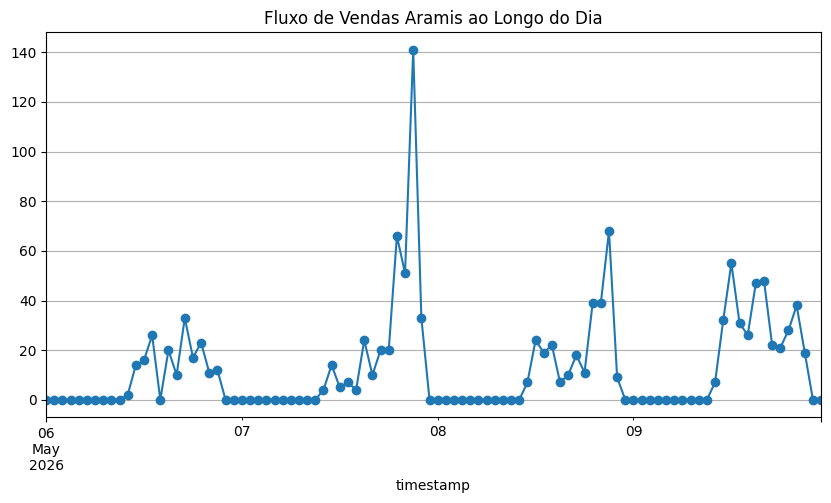

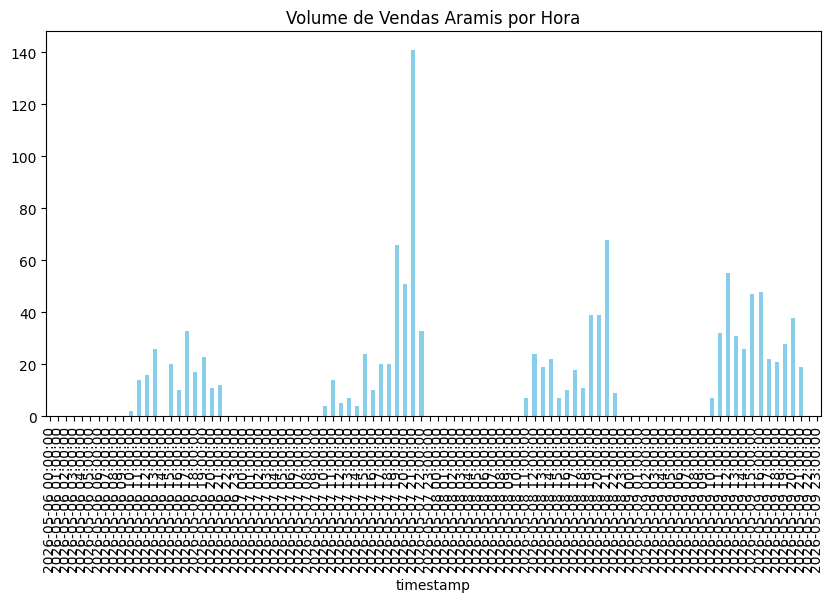

In [95]:
df_aramis['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Aramis ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_aramis['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Aramis por Hora')
plt.show()

In [96]:
df_janela_aramis = df[(df["loja"] == "Aramis") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_aramis = {
    'media_historica': df_janela_aramis['fluxo'].mean(),
    'desvio_padrao': df_janela_aramis['fluxo'].std(),
    'threshold_alerta': df_janela_aramis['fluxo'].mean() + (2.5 * df_janela_aramis['fluxo'].std())
}
print(stats_aramis)

{'media_historica': np.float64(23.653846153846153), 'desvio_padrao': np.float64(23.4260493647267), 'threshold_alerta': np.float64(82.21896956566292)}


In [97]:
# Executando o treino
modelo_aramis = treinar_melhor_ets(df_aramis['fluxo'])
print(f"Modelo treinado! AIC: {modelo_aramis.aic}")

Modelo treinado! AIC: 544.544215471201


In [98]:
hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_aramis.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")


Previsão para 2026-05-10 02:00:00: 0


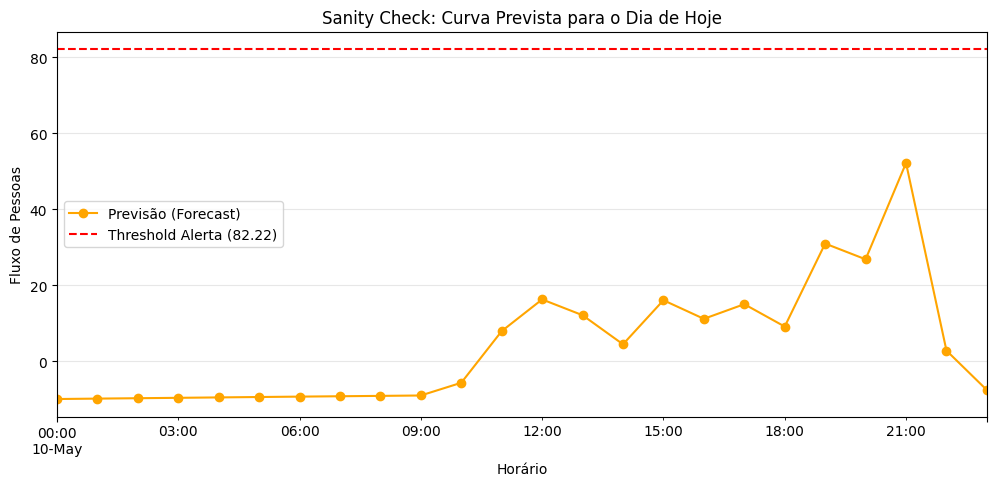

Pico previsto para hoje:
2026-05-10 21:00:00    52.201713
2026-05-10 19:00:00    30.992685
2026-05-10 20:00:00    26.852060
dtype: float64


In [99]:
previsao_hoje_aramis = modelo_aramis.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_aramis.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_aramis['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_aramis.sort_values(ascending=False).head(3))

# Modelo Arezzo

In [100]:
df_arezzo = df[df['loja'] == 'Arezzo'].set_index('timestamp')
df_arezzo = df_arezzo.asfreq('h').fillna(0)

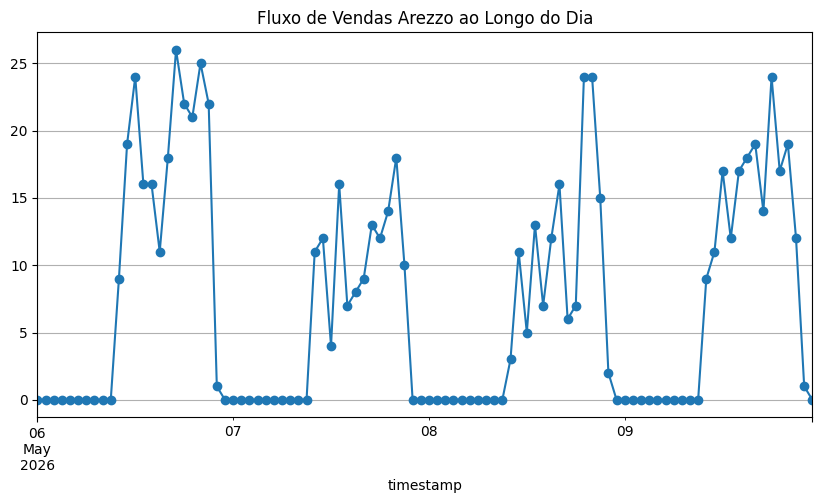

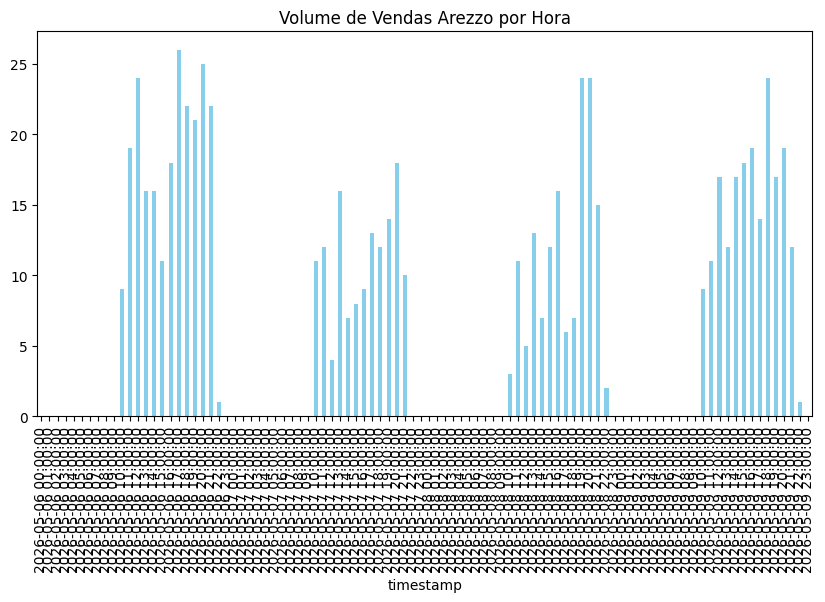

In [101]:
df_arezzo['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Arezzo ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_arezzo['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Arezzo por Hora')
plt.show()

In [102]:
df_janela_arezzo = df[(df["loja"] == "Arezzo") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_arezzo = {
    'media_historica': df_janela_arezzo['fluxo'].mean(),
    'desvio_padrao': df_janela_arezzo['fluxo'].std(),
    'threshold_alerta': df_janela_arezzo['fluxo'].mean() + (2.5 * df_janela_arezzo['fluxo'].std())
}
print(stats_arezzo)

{'media_historica': np.float64(13.442307692307692), 'desvio_padrao': np.float64(6.815246637283091), 'threshold_alerta': np.float64(30.48042428551542)}


In [103]:
# Executando o treino
modelo_arezzo = treinar_melhor_ets(df_arezzo['fluxo'])
print(f"Modelo treinado! AIC: {modelo_arezzo.aic}")

Modelo treinado! AIC: 275.2973402479163


In [104]:
hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_arezzo.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")

Previsão para 2026-05-10 02:00:00: 0


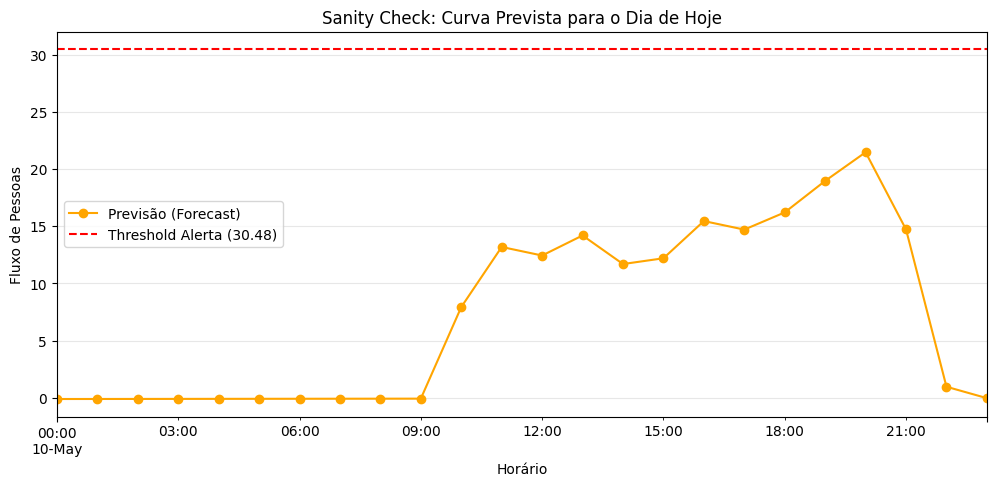

Pico previsto para hoje:
2026-05-10 20:00:00    21.458328
2026-05-10 19:00:00    18.955951
2026-05-10 18:00:00    16.202313
dtype: float64


In [105]:
previsao_hoje_arezzo = modelo_arezzo.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_arezzo.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_arezzo['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_arezzo.sort_values(ascending=False).head(3))

# Off Premium

In [106]:
df_off_premium = df[df['loja'] == 'Off Premium'].set_index('timestamp')
df_off_premium = df_off_premium.asfreq('h').fillna(0)


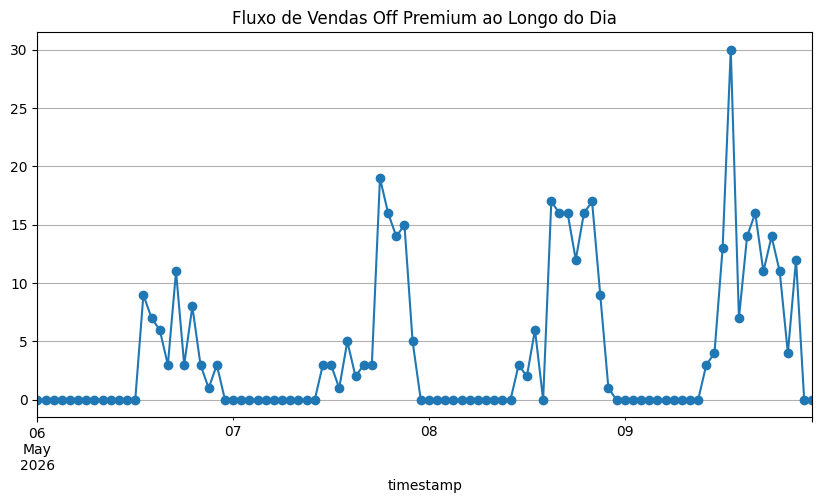

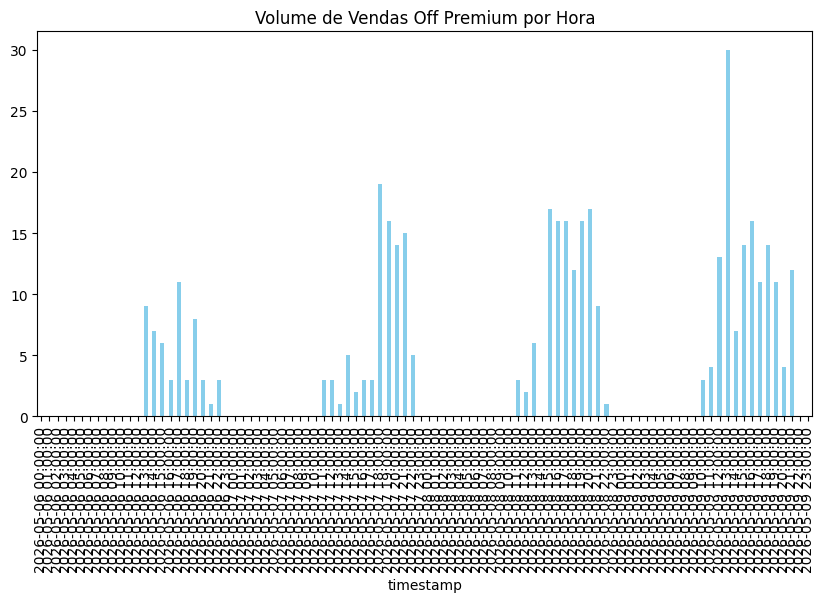

In [107]:
df_off_premium['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Off Premium ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_off_premium['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Off Premium por Hora')
plt.show()


In [108]:
df_janela_off_premium = df[(df["loja"] == "Off Premium") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_off_premium = {
    'media_historica': df_janela_off_premium['fluxo'].mean(),
    'desvio_padrao': df_janela_off_premium['fluxo'].std(),
    'threshold_alerta': df_janela_off_premium['fluxo'].mean() + (2.5 * df_janela_off_premium['fluxo'].std())
}
print(stats_off_premium)


{'media_historica': np.float64(7.634615384615385), 'desvio_padrao': np.float64(6.715591592511097), 'threshold_alerta': np.float64(24.42359436589313)}


In [109]:
# Executando o treino
modelo_off_premium = treinar_melhor_ets(df_off_premium['fluxo'])
print(f"Modelo treinado! AIC: {modelo_off_premium.aic}")

hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_off_premium.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")


Modelo treinado! AIC: 305.46803804313674
Previsão para 2026-05-10 02:00:00: 0


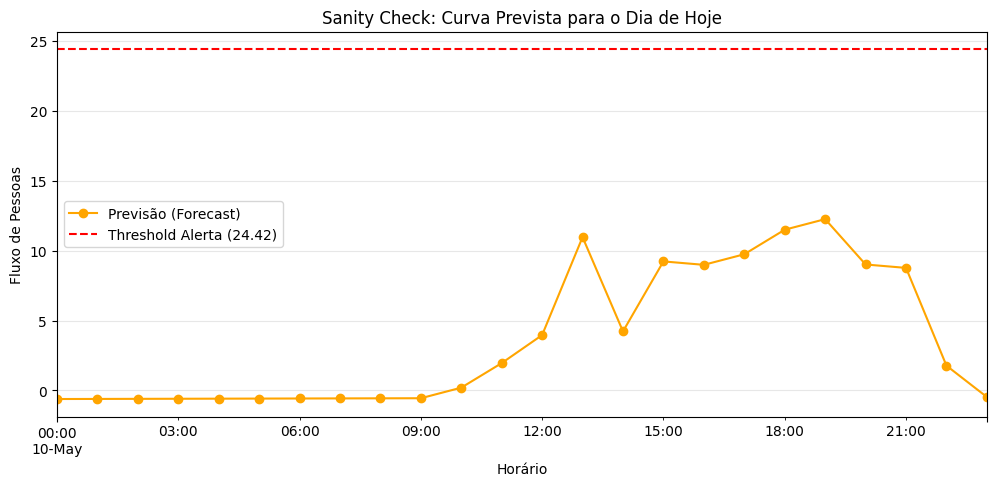

Pico previsto para hoje:
2026-05-10 19:00:00    12.253855
2026-05-10 18:00:00    11.497675
2026-05-10 13:00:00    10.966735
dtype: float64


In [110]:
previsao_hoje_off_premium = modelo_off_premium.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_off_premium.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_off_premium['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_off_premium.sort_values(ascending=False).head(3))

# Modelo Ida

In [111]:
df_ida = df[df['loja'] == 'Ida'].set_index('timestamp')
df_ida = df_ida.asfreq('h').fillna(0)

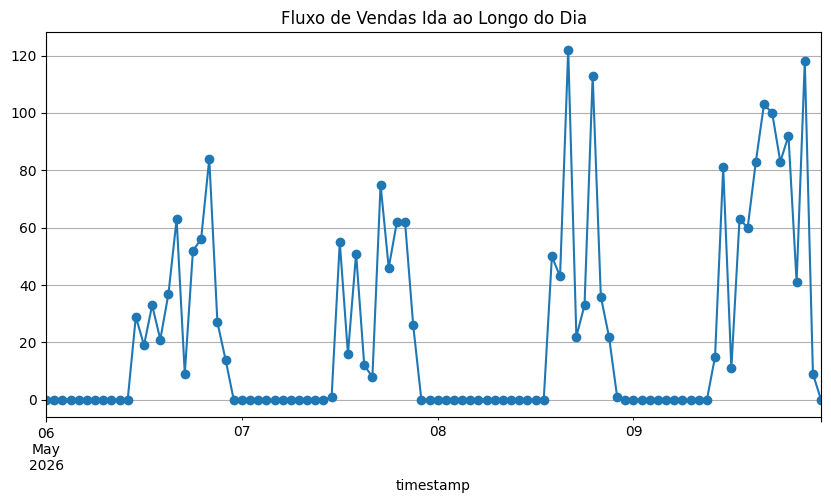

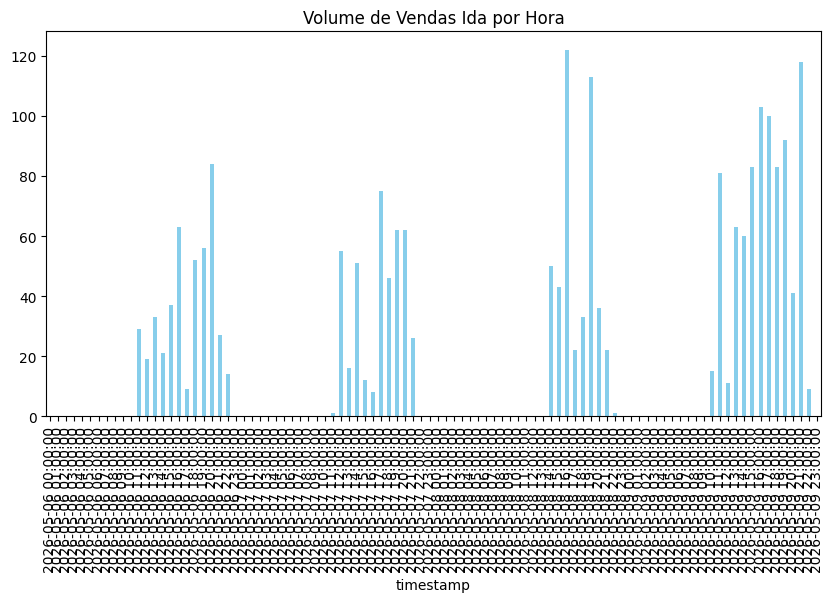

In [112]:
df_ida['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Ida ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_ida['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Ida por Hora')
plt.show()


In [113]:
df_janela_ida = df[(df["loja"] == "Ida") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_ida = {
    'media_historica': df_janela_ida['fluxo'].mean(),
    'desvio_padrao': df_janela_ida['fluxo'].std(),
    'threshold_alerta': df_janela_ida['fluxo'].mean() + (2.5 * df_janela_ida['fluxo'].std())
}
print(stats_ida)


{'media_historica': np.float64(41.51923076923077), 'desvio_padrao': np.float64(35.11800297183789), 'threshold_alerta': np.float64(129.31423819882548)}


In [114]:
# Executando o treino
modelo_ida = treinar_melhor_ets(df_ida['fluxo'])
print(f"Modelo treinado! AIC: {modelo_ida.aic}")

hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_ida.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")

Modelo treinado! AIC: 614.001955072279
Previsão para 2026-05-10 02:00:00: 19.6876054683147


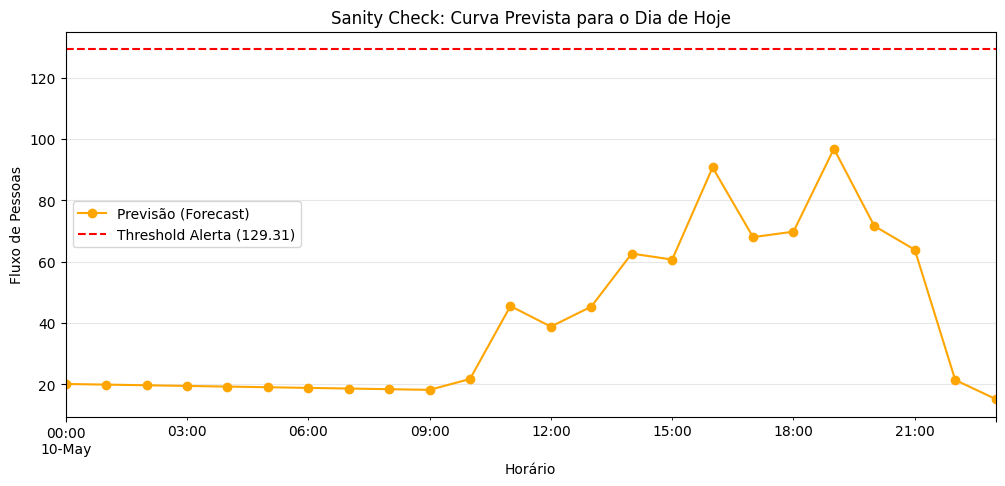

Pico previsto para hoje:
2026-05-10 19:00:00    96.808625
2026-05-10 16:00:00    90.698677
2026-05-10 20:00:00    71.594921
dtype: float64


In [115]:
previsao_hoje_ida = modelo_ida.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_ida.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_ida['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_ida.sort_values(ascending=False).head(3))

# Modelo Vans

In [116]:
df_vans = df[df['loja'] == 'Vans'].set_index('timestamp')
df_vans = df_vans.asfreq('h').fillna(0)

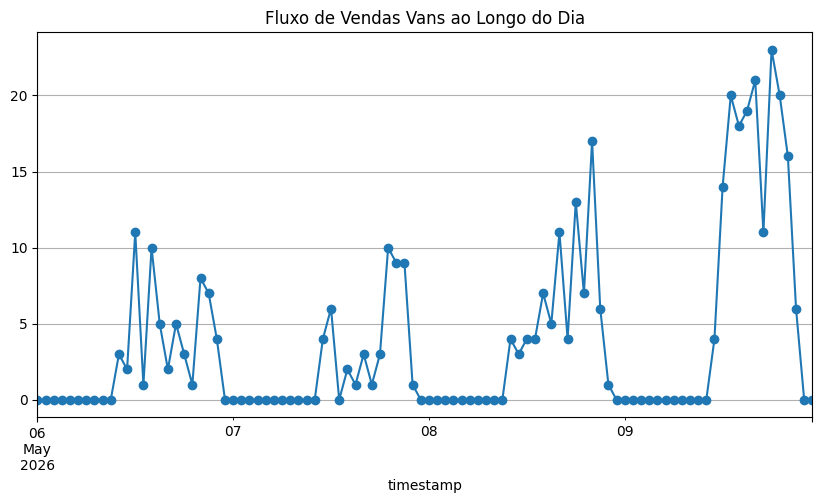

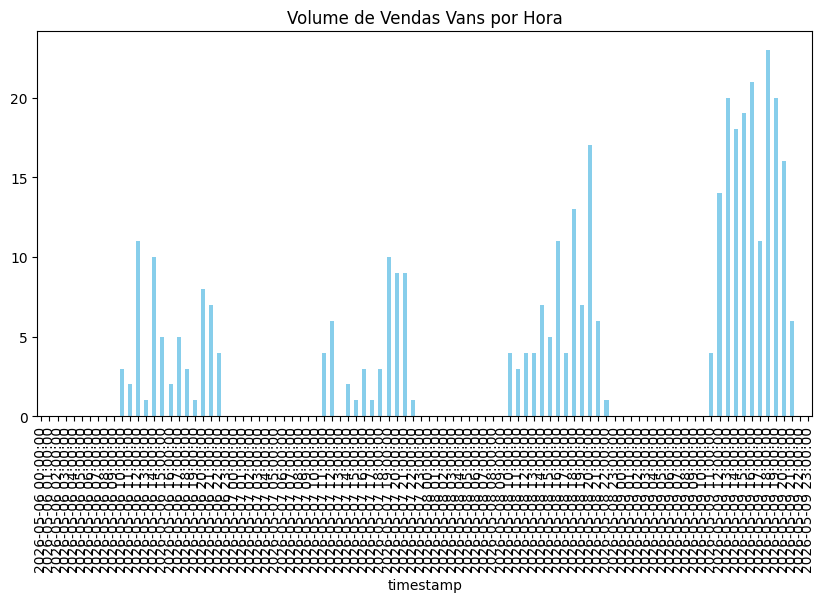

In [117]:
df_vans['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Vans ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_vans['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Vans por Hora')
plt.show()

In [118]:
df_janela_vans = df[(df["loja"] == "Vans") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_vans = {
    'media_historica': df_janela_vans['fluxo'].mean(),
    'desvio_padrao': df_janela_vans['fluxo'].std(),
    'threshold_alerta': df_janela_vans['fluxo'].mean() + (2.5 * df_janela_vans['fluxo'].std())
}
print(stats_vans)


{'media_historica': np.float64(7.096153846153846), 'desvio_padrao': np.float64(6.325360147491613), 'threshold_alerta': np.float64(22.909554214882878)}


In [119]:
# Executando o treino
modelo_vans = treinar_melhor_ets(df_vans['fluxo'])
print(f"Modelo treinado! AIC: {modelo_vans.aic}")

hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_vans.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")

Modelo treinado! AIC: 254.63643081851745
Previsão para 2026-05-10 02:00:00: 0


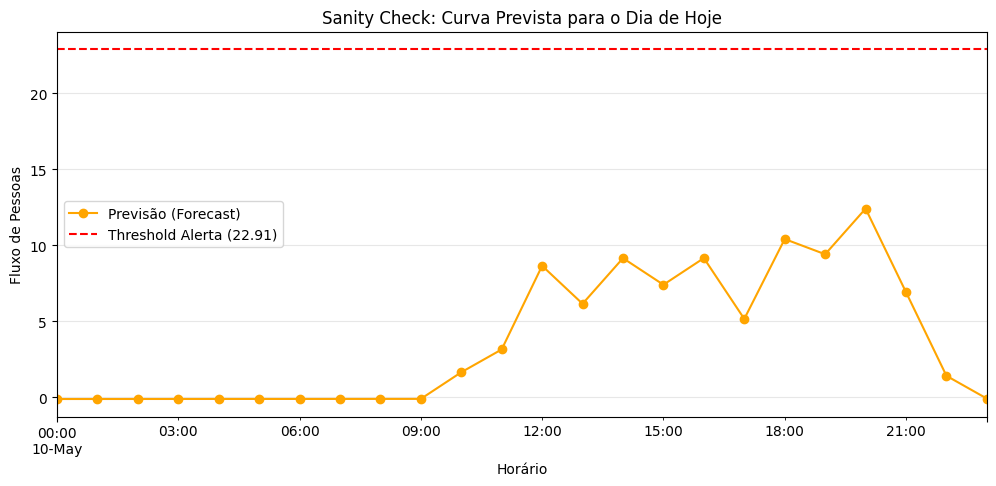

Pico previsto para hoje:
2026-05-10 20:00:00    12.412164
2026-05-10 18:00:00    10.410484
2026-05-10 19:00:00     9.411191
dtype: float64


In [120]:
previsao_hoje_vans = modelo_vans.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_vans.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_vans['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_vans.sort_values(ascending=False).head(3))

# Modelo High

In [121]:
df_high = df[df['loja'] == 'High'].set_index('timestamp')
df_high = df_high.asfreq('h').fillna(0)

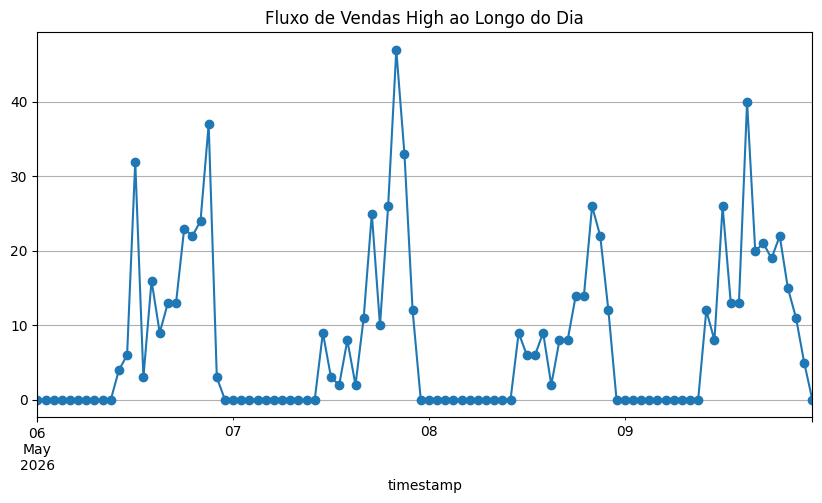

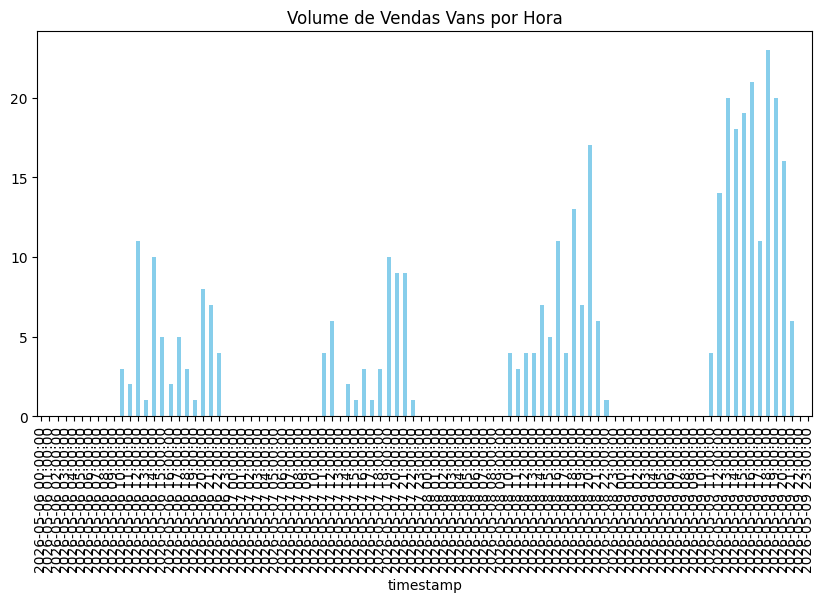

In [122]:
df_high['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas High ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_vans['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Vans por Hora')
plt.show()


In [123]:
df_janela_high = df[(df["loja"] == "High") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_high = {
    'media_historica': df_janela_high['fluxo'].mean(),
    'desvio_padrao': df_janela_high['fluxo'].std(),
    'threshold_alerta': df_janela_high['fluxo'].mean() + (2.5 * df_janela_high['fluxo'].std())
}
print(stats_high)


{'media_historica': np.float64(14.5), 'desvio_padrao': np.float64(10.72014778944073), 'threshold_alerta': np.float64(41.300369473601826)}


In [124]:
modelo_high = treinar_melhor_ets(df_high['fluxo'])
print(f"Modelo treinado! AIC: {modelo_high.aic}")

hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_high.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")

Modelo treinado! AIC: 390.822451566011
Previsão para 2026-05-10 02:00:00: 0


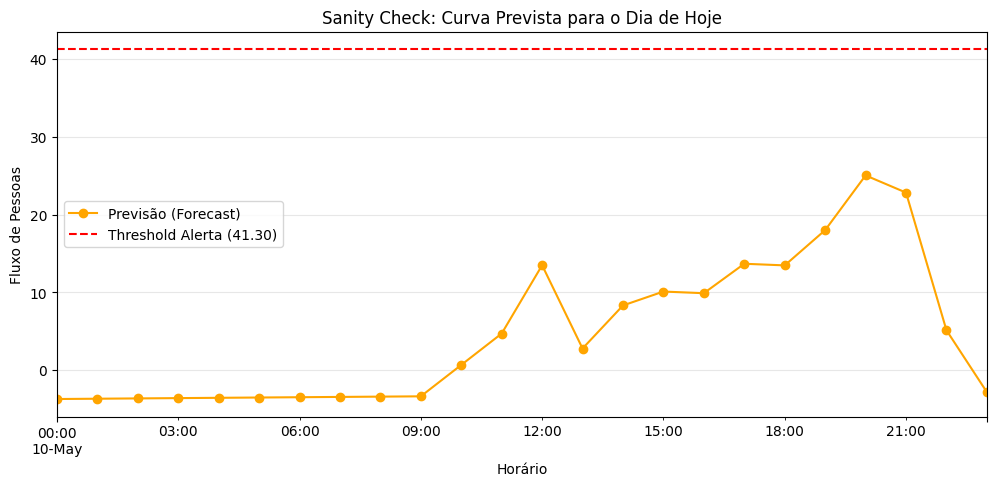

Pico previsto para hoje:
2026-05-10 20:00:00    25.040373
2026-05-10 21:00:00    22.827962
2026-05-10 19:00:00    18.003014
dtype: float64


In [125]:
previsao_hoje_high = modelo_high.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_high.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_high['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_high.sort_values(ascending=False).head(3))

# Modelo Vix

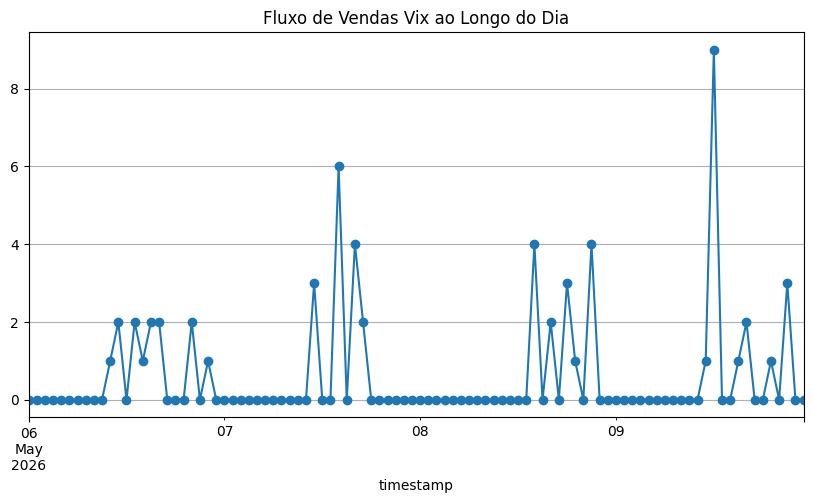

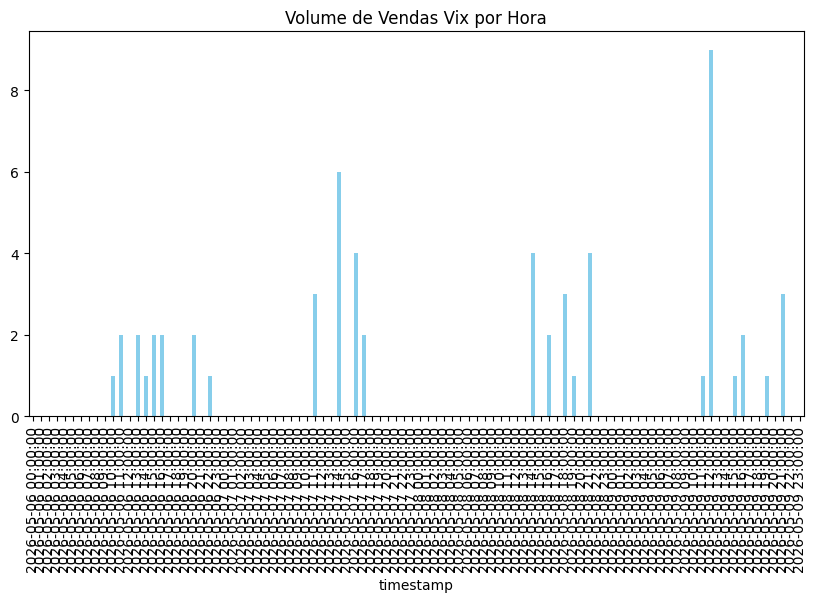

In [126]:
df_vix = df[df['loja'] == 'Vix'].set_index('timestamp')
df_vix = df_vix.asfreq('h').fillna(0)

df_vix['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Vix ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_vix['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Vix por Hora')
plt.show()


In [127]:
df_janela_vix = df[(df["loja"] == "Vix") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_vix = {
    'media_historica': df_janela_vix['fluxo'].mean(),
    'desvio_padrao': df_janela_vix['fluxo'].std(),
    'threshold_alerta': df_janela_vix['fluxo'].mean() + (2.5 * df_janela_vix['fluxo'].std())
}
print(stats_vix)


{'media_historica': np.float64(1.1346153846153846), 'desvio_padrao': np.float64(1.793548855266915), 'threshold_alerta': np.float64(5.618487522782672)}


In [128]:
# Executando o treino
modelo_vix = treinar_melhor_ets(df_vix['fluxo'])
print(f"Modelo treinado! AIC: {modelo_vix.aic}")

hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_vix.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")

Modelo treinado! AIC: 77.53250208624435
Previsão para 2026-05-10 02:00:00: 3.1719323045908965e-07


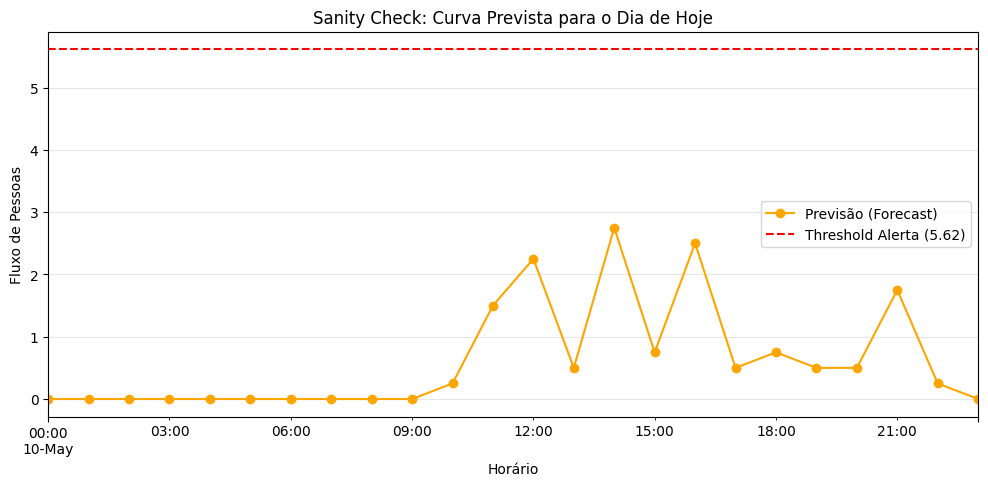

Pico previsto para hoje:
2026-05-10 14:00:00    2.750000
2026-05-10 16:00:00    2.500000
2026-05-10 12:00:00    2.249999
dtype: float64


In [129]:
previsao_hoje_vix = modelo_vix.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_vix.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_vix['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_vix.sort_values(ascending=False).head(3))

# Modelo Surto dos 50

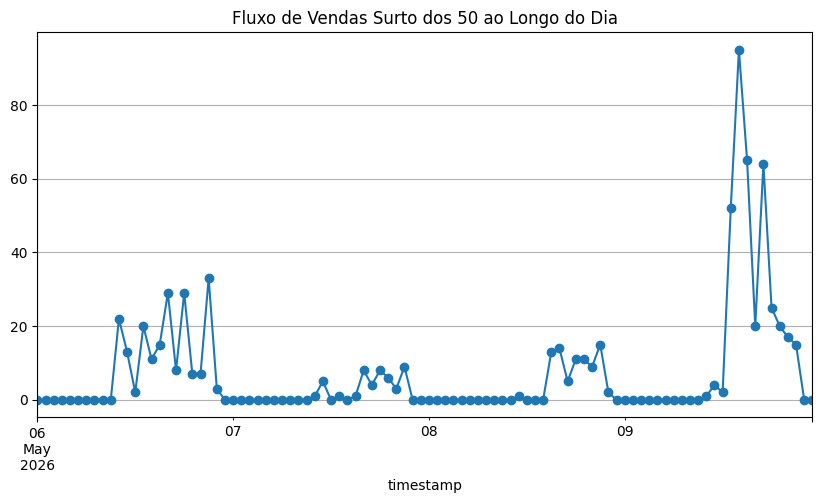

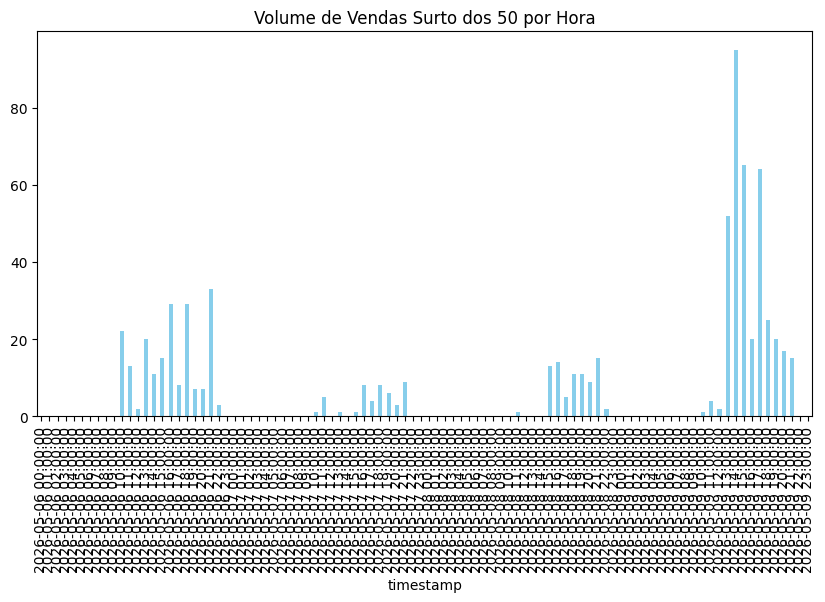

In [130]:
df_surto = df[df['loja'] == 'Surto dos 50'].set_index('timestamp')
df_surto = df_surto.asfreq('h').fillna(0)

df_surto['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Vendas Surto dos 50 ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df_surto['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Vendas Surto dos 50 por Hora')
plt.show()


In [131]:
df_janela_surto = df[(df["loja"] == "Surto dos 50") & (df["timestamp"].dt.hour >= 10) & (df["timestamp"].dt.hour <= 22)]

stats_surto = {
    'media_historica': df_janela_surto['fluxo'].mean(),
    'desvio_padrao': df_janela_surto['fluxo'].std(),
    'threshold_alerta': df_janela_surto['fluxo'].mean() + (2.5 * df_janela_surto['fluxo'].std())
}
print(stats_surto)


{'media_historica': np.float64(13.576923076923077), 'desvio_padrao': np.float64(18.792307723177437), 'threshold_alerta': np.float64(60.55769238486667)}


In [132]:
# Executando o treino
modelo_surto = treinar_melhor_ets(df_surto['fluxo'])
print(f"Modelo treinado! AIC: {modelo_surto.aic}")

hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_surto.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")

Modelo treinado! AIC: 499.3557305722044
Previsão para 2026-05-10 02:00:00: 12.372129419880675


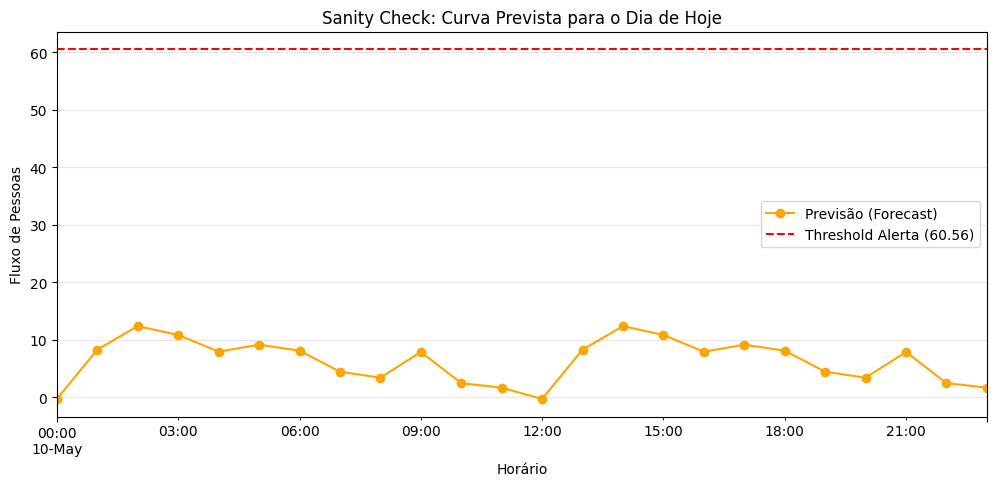

Pico previsto para hoje:
2026-05-10 02:00:00    12.372129
2026-05-10 14:00:00    12.372129
2026-05-10 15:00:00    10.835524
dtype: float64


In [133]:
previsao_hoje_surto = modelo_surto.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje_surto.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_surto['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje_surto.sort_values(ascending=False).head(3))

# Salvar no Banco

In [134]:
dados_previsao = []

previsoes_objetos = {
    "Aramis": previsao_hoje_aramis,
    "Arezzo": previsao_hoje_arezzo,
    "Off Premium": previsao_hoje_off_premium,
    "Ida": previsao_hoje_ida,
    "Vans": previsao_hoje_vans,
    "High": previsao_hoje_high,
    "Vix": previsao_hoje_vix,
    "Surto dos 50": previsao_hoje_surto
}

agora = datetime.now()

for nome_loja, objeto_previsao in previsoes_objetos.items():
    for ts, valor in zip(objeto_previsao.index, objeto_previsao.values):
        dados_previsao.append({
            'loja': nome_loja,
            'previsao': valor,
            'timestamp_previsao': ts,
            'criado_em': agora
        })

df_bd = pd.DataFrame(dados_previsao)

db = SessionLocal()

try:
    df_bd.to_sql("previsoes_vendas", db.bind, if_exists='append', index=False)
    print("-"*30)
    print("Previsões salvas com sucesso!")
    print(f"Total de registros: {len(df_bd)}")
    print(f"Lojas: {', '.join(df_bd['loja'].unique())}")
    print("-" * 30)
except Exception as e:
    print(f"Erro ao salvar previsões: {e}")
finally:
    db.close()

------------------------------
Previsões salvas com sucesso!
Total de registros: 192
Lojas: Aramis, Arezzo, Off Premium, Ida, Vans, High, Vix, Surto dos 50
------------------------------


# Salvando Modelos

In [135]:
joblib.dump(modelo_aramis, 'models/modelo_aramis.pkl')
joblib.dump(modelo_arezzo, 'models/modelo_arezzo.pkl')
joblib.dump(modelo_off_premium, 'models/modelo_off_premium.pkl')
joblib.dump(modelo_ida, 'models/modelo_ida.pkl')
joblib.dump(modelo_vans, 'models/modelo_vans.pkl')
joblib.dump(modelo_high, 'models/modelo_high.pkl')
joblib.dump(modelo_vix, 'models/modelo_vix.pkl')
joblib.dump(modelo_surto, 'models/modelo_surto.pkl')

['models/modelo_surto.pkl']